<a href="https://colab.research.google.com/github/DeepaKunjayya/BigdataAI2025/blob/DataAnalysis2025/Module3_assignment_BostonDataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving BostonHousing.csv to BostonHousing.csv
=== First 5 rows ===
+-------+----+-----+----+-----+-----+----+------+---+---+-------+------+-----+----+
|   crim|  zn|indus|chas|  nox|   rm| age|   dis|rad|tax|ptratio|     b|lstat|medv|
+-------+----+-----+----+-----+-----+----+------+---+---+-------+------+-----+----+
|0.00632|18.0| 2.31|   0|0.538|6.575|65.2|  4.09|  1|296|   15.3| 396.9| 4.98|24.0|
|0.02731| 0.0| 7.07|   0|0.469|6.421|78.9|4.9671|  2|242|   17.8| 396.9| 9.14|21.6|
|0.02729| 0.0| 7.07|   0|0.469|7.185|61.1|4.9671|  2|242|   17.8|392.83| 4.03|34.7|
|0.03237| 0.0| 2.18|   0|0.458|6.998|45.8|6.0622|  3|222|   18.7|394.63| 2.94|33.4|
|0.06905| 0.0| 2.18|   0|0.458|7.147|54.2|6.0622|  3|222|   18.7| 396.9| 5.33|36.2|
+-------+----+-----+----+-----+-----+----+------+---+---+-------+------+-----+----+
only showing top 5 rows

=== Number of observations: 506 ===
=== Schema ===
root
 |-- crim: double (nullable = true)
 |-- zn: double (nullable = true)
 |-- indus: double (nullab

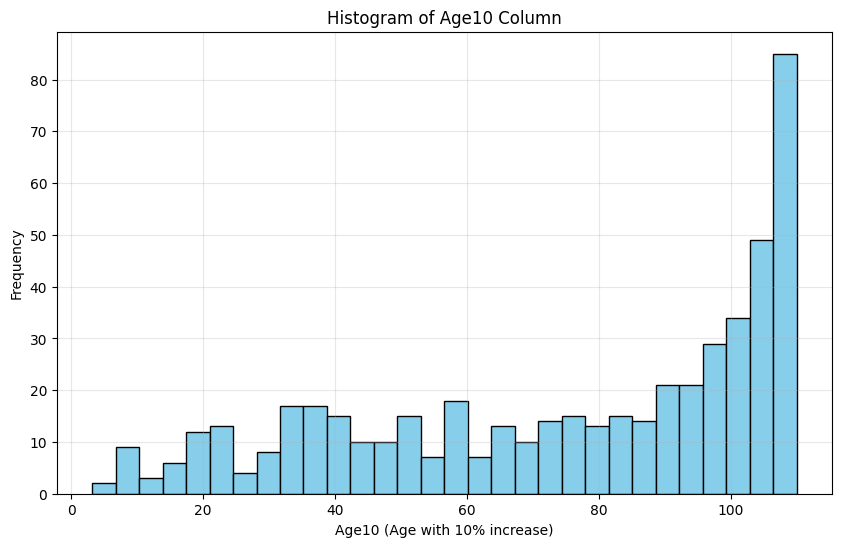

=== Summary Statistics ===
+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+
|summary|              crim|                zn|             indus|              chas|               nox|                rm|               age|               dis|              rad|               tax|           ptratio|             lstat|              medv|             Age10|
+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+
|  count|               506|               506|               506|               506|               506|               506|               506|      

In [1]:
# Install PySpark
!pip install pyspark

# Import libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, round as spark_round
import matplotlib.pyplot as plt
import pandas as pd

# Create Spark Session
spark = SparkSession.builder \
    .appName("Boston Housing Analysis") \
    .master("local[*]") \
    .getOrCreate()

# Upload and read CSV
from google.colab import files
uploaded = files.upload()
df = spark.read.csv('BostonHousing.csv', header=True, inferSchema=True)

# 1. First 5 elements
print("=== First 5 rows ===")
df.show(5)

# 2. Count observations
print(f"=== Number of observations: {df.count()} ===")

# 3. Show Schema
print("=== Schema ===")
df.printSchema()

# 4. Drop column 'b'
df = df.drop('b')
print("=== Column 'b' dropped ===")

# 5. Round numerical columns to 2 decimal places
numeric_columns = [col_name for col_name in df.columns if col_name != 'chas']
for col_name in numeric_columns:
    df = df.withColumn(col_name, spark_round(col(col_name), 2))
print("=== Rounded to 2 decimal places ===")

# 6. Create Age10 column
df = df.withColumn('Age10', spark_round(col('age') * 1.10, 2))
print("=== Age10 column created ===")
df.show(5)

# 7. Plot histogram
age10_data = df.select('Age10').toPandas()
plt.figure(figsize=(10, 6))
plt.hist(age10_data['Age10'], bins=30, edgecolor='black', color='skyblue')
plt.xlabel('Age10 (Age with 10% increase)')
plt.ylabel('Frequency')
plt.title('Histogram of Age10 Column')
plt.grid(True, alpha=0.3)
plt.show()

# 8. Summary statistics
print("=== Summary Statistics ===")
df.describe().show()

# 9. Convert to Pandas
pandas_df = df.toPandas()
print("=== Converted to Pandas ===")

# 10. Last 5 rows
print("=== Last 5 rows ===")
print(pandas_df.tail(5))

In [2]:
print(spark.version)

3.5.1
